# Rossmann Store Sales: Preprocessing and EDA

This notebook has three parts. **Part A** describes and cleans the raw data, **Part B** explores it with visualizations and **Part C** creates the cleaned/preprocessed dataset that all four models (Seasonal Naive, Ridge, LightGBM, TFT) will use. 

And I made sure that the feature engineering and scaling parts are left for the modeling stage so that this way every model would train on the same base and nothing would leak.

# Part A: Data description and preparation

## A1. Loading the data and checking its structure

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
pd.set_option("display.max_columns",None)#for pandas no hidden cols
sns.set_theme(style='whitegrid')#for seaborn
#RAW=Path.cwd().parent
RAW=Path.cwd().parent / "data" / "raw"

In [3]:
# train loaded and Date parsed to column of real dates
train = pd.read_csv(RAW / "train.csv", parse_dates=['Date'],low_memory=False)
print(train.shape)

(1017209, 9)


In [4]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
# sales data date range (min and max)
print(train['Date'].min().date(), "to",train['Date'].max().date())

2013-01-01 to 2015-07-31


In [6]:
store = pd.read_csv(RAW / "store.csv") #store loaded
print(store.shape)

(1115, 10)


In [7]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 69.8+ MB


In [9]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [10]:
train["StateHoliday"].unique()# StateHoliday has 0 as well beside letter codes

array(['0', 'a', 'b', 'c'], dtype=object)

In [11]:
# to make sure no mix up will occur
train["StateHoliday"] = train["StateHoliday"].astype(str)
train["StateHoliday"].unique()

array(['0', 'a', 'b', 'c'], dtype=object)

## A2. Column dictionary, target and summary of statistics

Target variable: **Sales** (daily sales) for each store (continuous / regression forecasting)

In [12]:
train.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01


In [13]:
store.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


## A3. Integrity checks

additional checking for possible flaws

In [14]:
print(train.duplicated(["Store", "Date"]).sum()) # no Store Date row duplicate

0


In [15]:
print((train["Date"].dt.dayofweek +1 == train['DayOfWeek']).all())
# weekday column safe

True


In [16]:
print(train["Open"].unique())
print(train["Promo"].unique())
print(train["SchoolHoliday"].unique())
# all clean only 1 and 0

[1 0]
[1 0]
[1 0]


In [17]:
# clean min and max Sales vals
print(train['Sales'].min(),train['Sales'].max())

0 41551


In [18]:
# merging both files (store and train) is safe
print(set(train['Store'])==set(store["Store"]))

True


## A4. Missing Values and Merging

In [19]:
train.isna().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [20]:
# missing values are only in store detail columns in store.csv,
# so they should be handled before merging
store.isna().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [21]:
# 544 of the stores did not participated in promo2 at all
# so the 544 missings in promo2 detail columns is expected
print((store['Promo2']==0).sum())

544


In [22]:
# from the stores that didn't participate in promo2
# all of them are also missing Promo2SinceWeek
# this again shows the missing values are not random
print(store.loc[store["Promo2"] == 0, "Promo2SinceWeek"].isna().sum())

544


It isn't needed to keep the messy Promo2 detail columns (Promo2SinceWeek, Promo2SinceYear, PromoInterval) and only Promo2 column itself is enough for this project

Also, CompetitionOpenSinceMonth and CompetitionOpenSinceYear have too many missing vals (354) and they are not reliable enuogh or helpful

In [23]:
store_clean=store.copy()
store_clean = store_clean.drop(columns=["CompetitionOpenSinceMonth", "CompetitionOpenSinceYear","Promo2SinceWeek", "Promo2SinceYear", "PromoInterval"])

CompetitionDistance has only 3 missing values, therefore it is still a useful column and I will fill those few missings with the median competition dist

In [24]:
store_clean['CompetitionDistance'] = store_clean['CompetitionDistance'].fillna(store["CompetitionDistance"].median())

Now merging store and train (daily) data

In [25]:
df = train.merge(store_clean,on='Store', how="left")
print(df.shape) # now every daily sales row has extra store info added

(1017209, 13)


In [26]:
# no missing vals after merging
print(df.isna().sum().sum())

0


## A5. Closed days rows and Zero sales rows

When the store is closed (Open=0) it is expected to have 0 Sales

In [27]:
# making sure all close days have 0 Sales as expected
print(df['Open'].value_counts())
print(((df['Open']==0) & (df["Sales"]==0)).sum())#closed no sales (correctly all)
print(((df['Open']==0) & (df["Sales"]>0)).sum())# closed with sales (correctly 0)

Open
1    844392
0    172817
Name: count, dtype: int64
172817
0


One thing that would be very likely error if it exists is if there are cases that Open = 1 but Sales = 0 and Customers = 0 because that is very unusual

In [28]:
print(((df['Open']==1) & (df["Sales"]==0)).sum())
# I will drop because they are few and not useful for learning/training
# they are not normal sales behaviour
df = df[~((df['Open']==1) & (df["Sales"]==0))]
print(((df['Open']==1) & (df["Sales"]==0)).sum())
print("kept rows", len(df))

54
0
kept rows 1017155


In [29]:
#creating open_df for eda part (part B)
open_df = df[df['Open']==1]
print(len(open_df))#open day rows for eda

844338


## A6. Date continuity per store

Making sure each store has a row for each day (no missing dates / gaps)

In [30]:
#each store's date row counts
days_per_store = train.groupby("Store")['Date'].count()

In [31]:
# total days count
print((train['Date'].max()-train['Date'].min()).days+1)
#print((train['Date'].max()-train['Date'].min()).days)

942


In [32]:
# 934 stores correctly have all 942 days
# 181 stores have missing dates (one of them just missing 1 date)
print(days_per_store.value_counts())

Date
942    934
758    180
941      1
Name: count, dtype: int64


In [33]:
# one store that has missing date as example to see missing dates of it
short_store = days_per_store[days_per_store==758].index[0]
one = train[train["Store"]==short_store]
#print(short_store)
#print(len(one))
fullRange = pd.date_range(one['Date'].min(),one['Date'].max())
gap = fullRange.difference(one['Date'])
print(gap.min().date(), gap.max().date())#missing portion/range

2014-07-01 2014-12-31


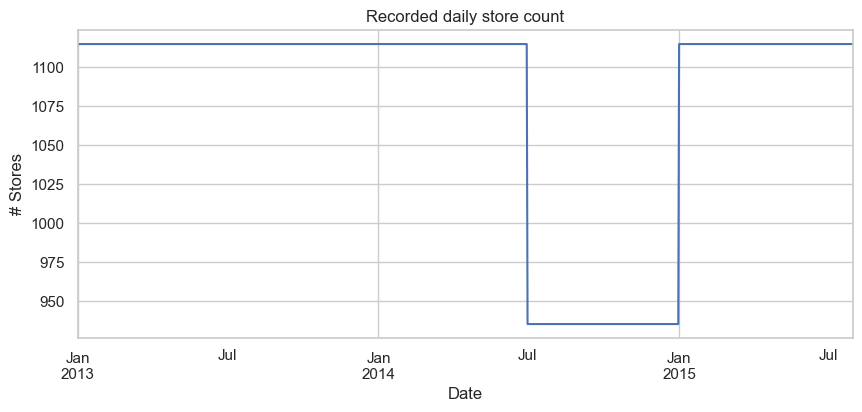

In [34]:
plt.figure(figsize=(10,4))
train.groupby('Date').size().plot()
plt.title("Recorded daily store count")
plt.ylabel("# Stores")
plt.show()

Number of stores that are recorded for each day are mostly stable, the only thing is that there is a drop from July until December 2014 (many stores have missing date rows during that time)

Issue fixed in part C

# Part B: Exploratory Data Analysis (EDA)

## B1. The target: Sales

In [35]:
print(open_df['Sales'].describe())

count    844338.000000
mean       6955.959134
std        3103.815515
min          46.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64


In [36]:
print(round(open_df["Sales"].skew(),2))#right skewed

1.59


In [37]:
#percentilies
print("95, 99, 99.9" , [round(open_df['Sales'].quantile(q)) for q in [0.95,0.99, 0.999]])

95, 99, 99.9 [12668, 17789, 24669]


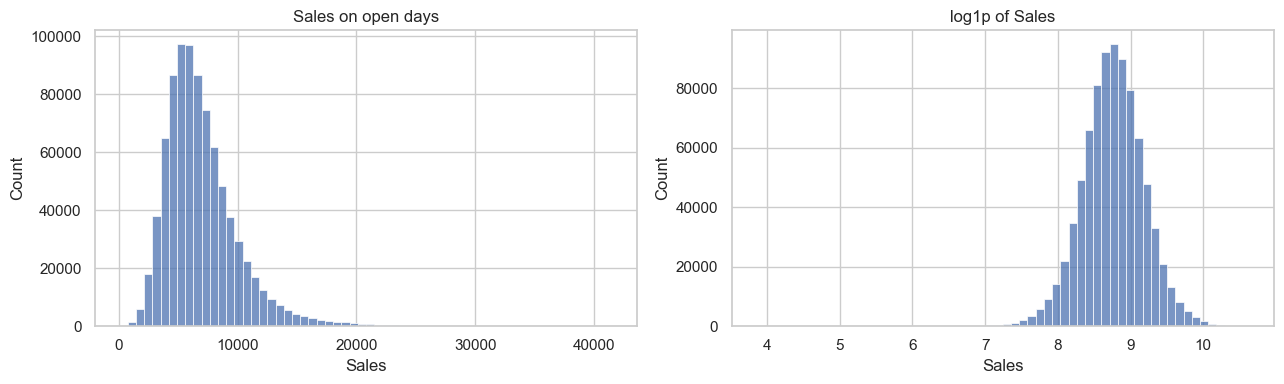

In [38]:
fig, axes = plt.subplots(1,2, figsize=(13,4))
# raw sales vs log transformed sales to see dist changes after log1p
sns.histplot(open_df['Sales'], bins= 60,ax=axes[0])
axes[0].set_title("Sales on open days")
sns.histplot(np.log1p(open_df['Sales']), bins=60,ax=axes[1])
axes[1].set_title("log1p of Sales")
plt.tight_layout()
plt.show()

raw open day sales are right skewed, and on the other hand the log version has changed the shape but it didn't clearly improve it, it instead overvorrected it into a left skew.

## B2. The predictors

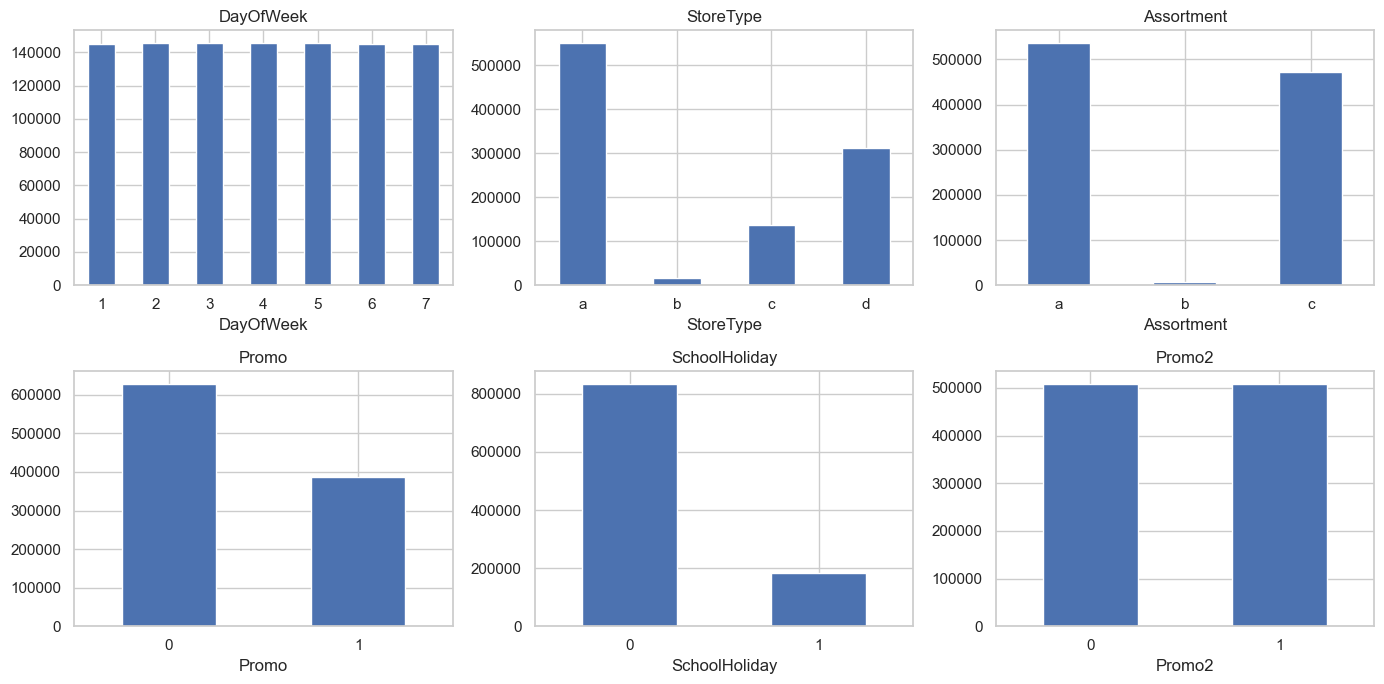

In [39]:
#count of main predictors
fig, axes = plt.subplots(2,3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), ["DayOfWeek","StoreType","Assortment","Promo",'SchoolHoliday', 'Promo2']):
    df[col].value_counts().sort_index().plot(kind='bar',ax=ax, title = col, rot=0)
plt.tight_layout()
plt.show()# some of them are daily changing features and others are store level

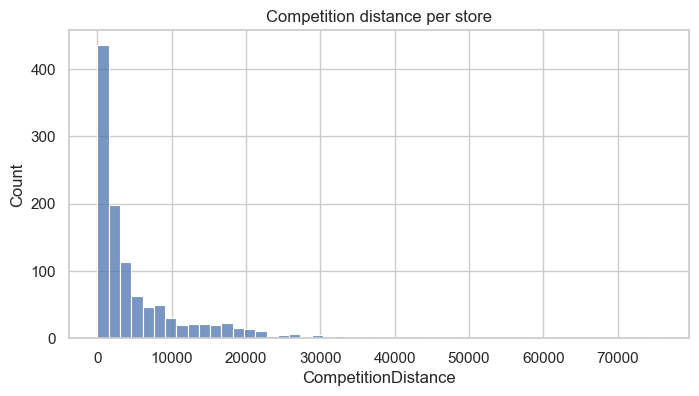

In [40]:
plt.figure(figsize=(8,4))
sns.histplot(store_clean['CompetitionDistance'],bins= 50)
plt.title("Competition distance per store")
plt.show() 
# most of the stores have competitors near them

## B3. Temporal patterns

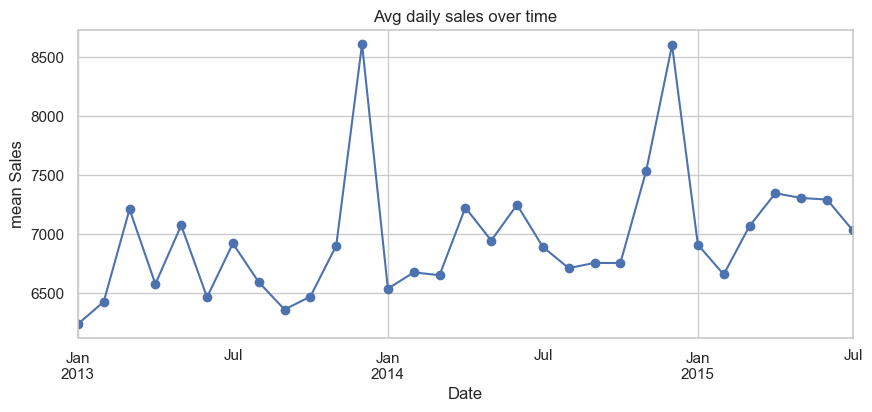

In [41]:
monthly = open_df.groupby(open_df['Date'].dt.to_period("M"))['Sales'].mean()
monthly.index=monthly.index.to_timestamp()
monthly.plot(figsize=(10,4), marker='o', title = "Avg daily sales over time")
plt.ylabel("mean Sales")
plt.show()
# sales roughly stay the same most months, but they have clear jumps in decembers probably because of christmas

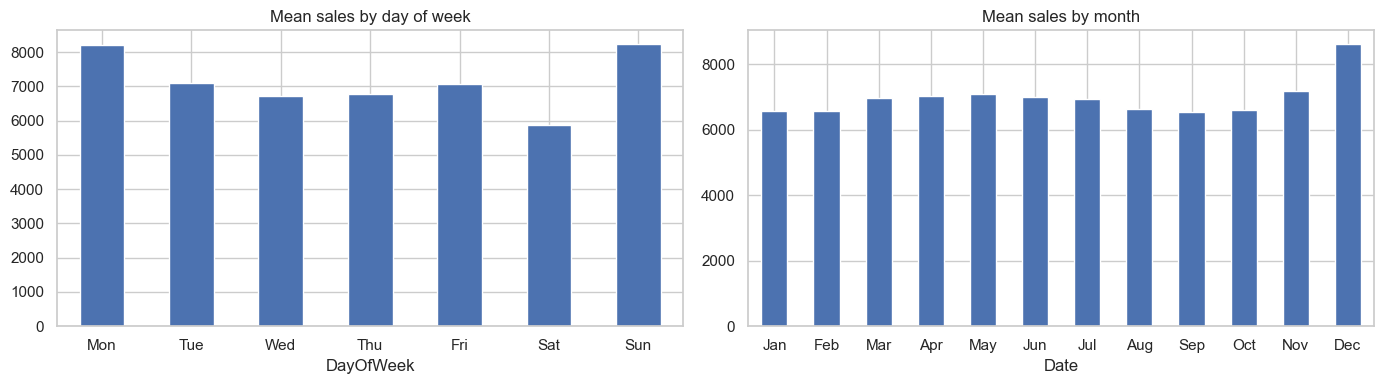

In [42]:
#avg sales for every day of week and for every month
fig,axes = plt.subplots(1,2, figsize=(14, 4))
open_df.groupby("DayOfWeek")["Sales"].mean().plot(kind="bar", ax = axes[0], title="Mean sales by day of week")
axes[0].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat","Sun"], rotation =0)
open_df.groupby(open_df['Date'].dt.month)["Sales"].mean().plot(kind='bar', ax=axes[1],title="Mean sales by month")
axes[1].set_xticklabels(["Jan", "Feb", "Mar", "Apr","May","Jun","Jul","Aug", "Sep", "Oct", "Nov", "Dec"], rotation =0)
plt.tight_layout()
plt.show()# monday and sunday highest, saturday lowest

In [43]:
# looking at one sample store (store 1) to seeing if its sales repeat has a pattern
# checking how similar each day is to the days before it (up to 28 days back)
oneStore = train[train["Store"]==1].sort_values('Date').set_index('Date')["Sales"].asfreq("D")
#oneStore = train[train["Store"]==1].sort_values('Date').set_index('Date')["Sales"]
lags = range(1,29)
acf = [oneStore.autocorr(lag) for lag in lags]

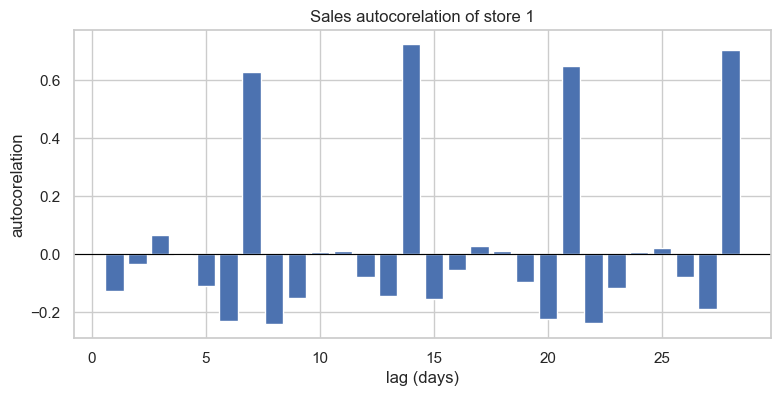

In [44]:
plt.figure(figsize=(9,4))
plt.bar(list(lags), acf)
#plt.bar(lags, acf)
plt.axhline(0,color='black', linewidth=0.8)
plt.title("Sales autocorelation of store 1")
plt.xlabel("lag (days)")
plt.ylabel('autocorelation')
plt.show()

There is a pattern for store 1. The vals jump every 7 days, so the sales repeat every week and for example todays sales look a lot like its one week ago (same day) sales. Using weekly lag might be helpful.

In [45]:
# avg sales on holiday days vs normal days for open stores
# holiday days are in 3 types a,b,c and normal days are 0
print(open_df.groupby('StateHoliday')['Sales'].mean().round(0))
print(open_df["StateHoliday"].value_counts())
# most stores are closed on holiday days
# and the few ones that are open have higher than avg sales compared to normal days

StateHoliday
0    6954.0
a    8487.0
b    9888.0
c    9744.0
Name: Sales, dtype: float64
StateHoliday
0    843428
a       694
b       145
c        71
Name: count, dtype: int64


In [46]:
#sales of open days with vs without school holidays (because school holidays dont close stores)
print(open_df.groupby("SchoolHoliday")['Sales'].mean().round(0))
# sales are only a little bit higher on school holidays not at all close to what a promo does

SchoolHoliday
0    6897.0
1    7201.0
Name: Sales, dtype: float64


## B4. Relationships and correlation

In [47]:
# avrg sales on promo days vs non promo days
promoMeans = open_df.groupby("Promo")['Sales'].mean()
print(promoMeans.round(0))

Promo
0    5930.0
1    8229.0
Name: Sales, dtype: float64


In [48]:
print(round((promoMeans[1]/promoMeans[0] -1)*100, 1))
# sales on promo days are around 39% more which shows they are very impactful

38.8


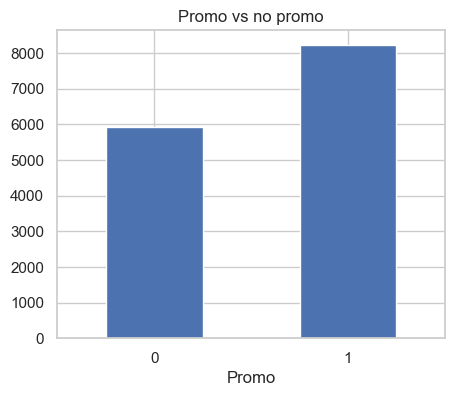

In [49]:
promoMeans.plot(kind='bar', figsize=(5,4), title="Promo vs no promo")
plt.xticks(rotation=0)
plt.show()

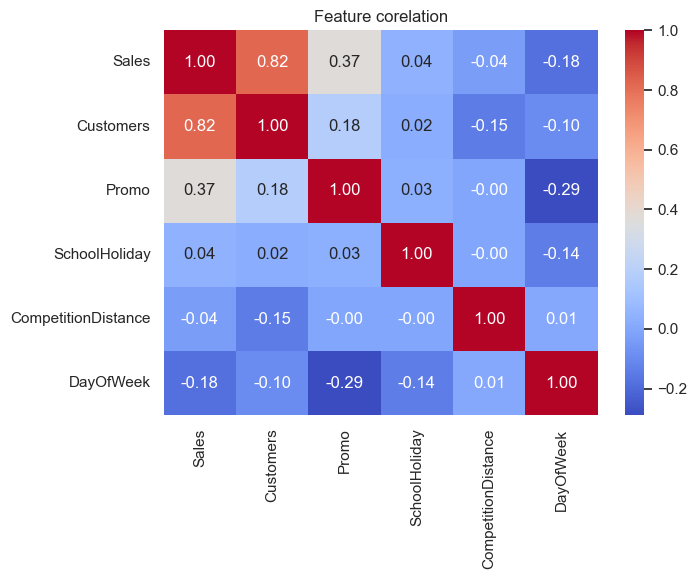

In [50]:
# corelation of numeric features with sales
num = open_df[["Sales","Customers","Promo","SchoolHoliday", 'CompetitionDistance','DayOfWeek']]
plt.figure(figsize=(7,5))
#sns.heatmap(num.corr(),annot=True, cmap= 'coolwarm')
sns.heatmap(num.corr(),annot=True, fmt=".2f", cmap= 'coolwarm')
plt.title("Feature corelation")
plt.show()
#Customers is the only one with clear strong corelation with Sales (positive cor)

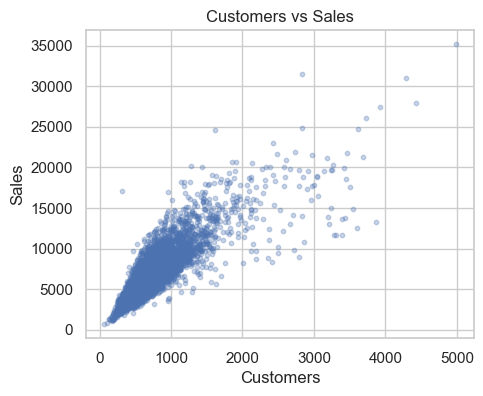

In [51]:
# customers vs sales on random sample of 5000 rows to make sure plot isn't too crowdy
sample = open_df.sample(5000,random_state=42)
plt.figure(figsize=(5,4))
plt.scatter(sample["Customers"],sample['Sales'], s=10, alpha=0.3)
#plt.scatter(sample["Customers"],sample['Sales'])
plt.xlabel("Customers")
plt.ylabel('Sales')
plt.title("Customers vs Sales")
plt.show()

Customers clearly have a positive corelation with Sales, but the problem is that Customers is not known in advance and using it would cause data leakage. So it should be dropped.

Also CompetitionDistance has a very weak corelation with Sales, but I kept it just in case the lightgbm would find something useful in it.

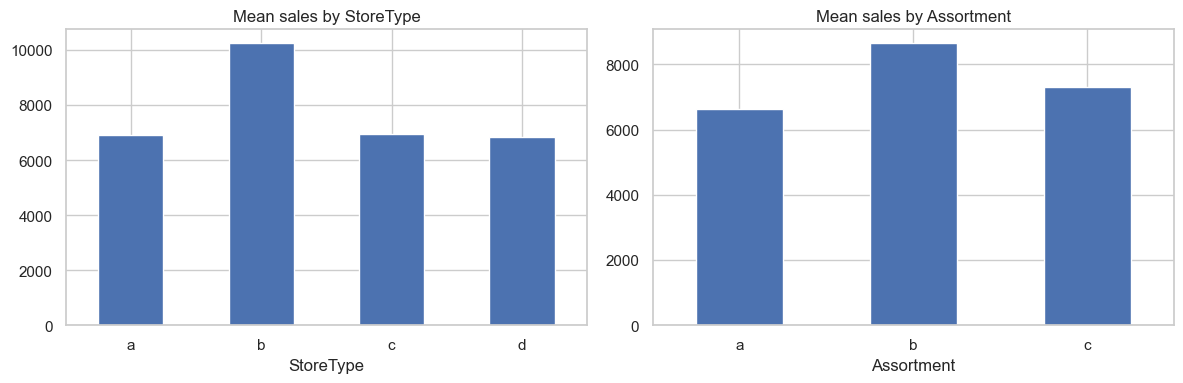

In [52]:
# avrg sales for each store type vs each assortment type
fig, axes = plt.subplots(1,2, figsize=(12,4))
open_df.groupby("StoreType")['Sales'].mean().plot(kind='bar',ax=axes[0], title="Mean sales by StoreType")
open_df.groupby("Assortment")['Sales'].mean().plot(kind='bar',ax=axes[1], title="Mean sales by Assortment")
axes[0].tick_params(axis='x',rotation=0)
axes[1].tick_params(axis='x',rotation=0)
plt.tight_layout()
plt.show() # sales vary
#store type b sells more than other store types

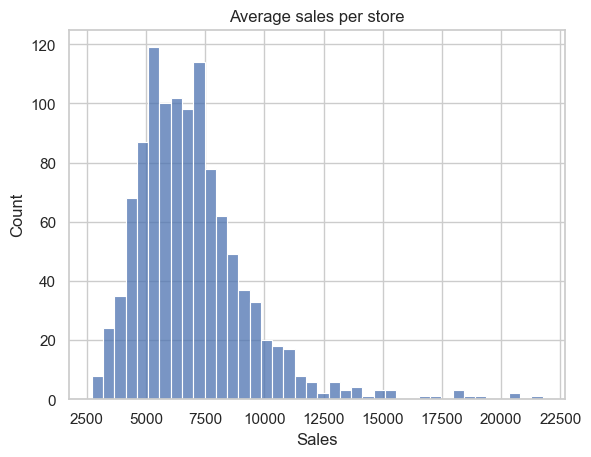

In [53]:
# avrg sales for each store
store_means = open_df.groupby("Store")['Sales'].mean()
sns.histplot(store_means,bins=40)
plt.title("Average sales per store")
plt.show()
#print(round(store_means.min()), round(store_means.max()), round(store_means.std()))

# the smallest store avrg is around 2700 and the biggest is around 21800 which shows the stores can be very different from each other in Sales

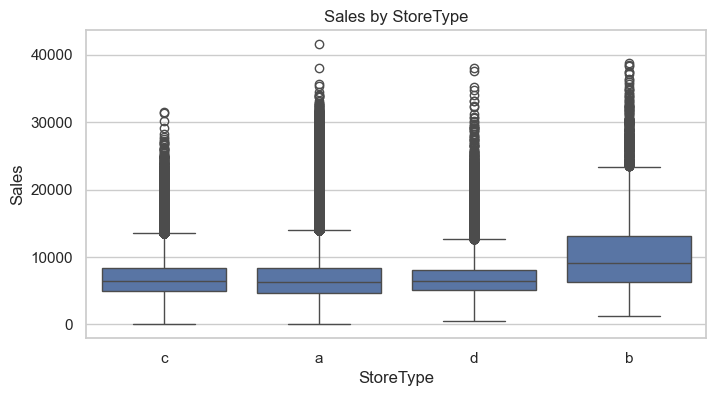

In [54]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="StoreType",y='Sales', data=open_df)
plt.title("Sales by StoreType")
plt.show()
# even inside the same store type the sales vary a lot

since stores are really different from each other instead of building a separate model for each store, I train one model for all of them and let it use the store features to be able to tell the stores apart

## B5. Multivariate: promo by day of week

checking if the effect of promo is the same on every weekday or it changes from day to day

In [55]:
# avrg sales of each weekday promo day vs no promo day
promo_by_day = open_df.groupby(["DayOfWeek","Promo"])['Sales'].mean().unstack()
print(promo_by_day.round(0))

Promo           0       1
DayOfWeek                
1          6223.0  9773.0
2          5716.0  8278.0
3          5618.0  7686.0
4          5751.0  7599.0
5          6344.0  7744.0
6          5875.0     NaN
7          8225.0     NaN


In [56]:
print(((promo_by_day[1]/promo_by_day[0] -1)*100).round(0))

DayOfWeek
1    57.0
2    45.0
3    37.0
4    32.0
5    22.0
6     NaN
7     NaN
dtype: float64


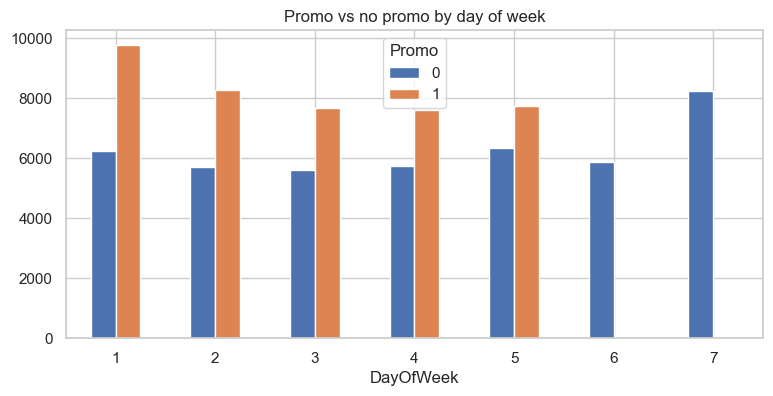

In [57]:
promo_by_day.plot(kind='bar',figsize=(9, 4), title="Promo vs no promo by day of week")
plt.xticks(rotation=0)
plt.show()

promo increases the sales on weekdays but the amount of that increase is not the same for every day, the biggest uplift is on monday and gets smaller later, so promo works better on some days than others.

## B6. Key EDA findings

- Sales is right skewed and log overcorrects it, so I will keep Sales as is
- the very high sales values should be kept since they are real and not errors
- there is clear weekly pattern and peak in december, so weekly lags and a seasonal baseline should help
- promo has strong effect
- on state holidays most stores are closed, so a holiday day usually means no sales on that day
- stores differ a lot, so one model should be used for all and with store features, not one per store
- Customers should be dropped to prevent leakage and CompetitionDistance has also a very weak corelation, but I kept it for lightgbm
- some stores had date gaps that should be fixed in part C

# Part C: Building the cleaned dataset

to fix the date gap issue that some stores had, I will rebuild a full daily calendar for every store. And to remain reliable, the added dates are going to be filled as closed days instead of random data. And they will also be flagged with was_present=False so I could drop them in training.

In [58]:
#full calender of each store paired with each date
day_cols = ["Store","Date","Sales","Open","Promo", 'StateHoliday','SchoolHoliday']
allDates=pd.date_range(train['Date'].min(), train['Date'].max())
full_index = pd.MultiIndex.from_product([sorted(df["Store"].unique()), allDates],names = ["Store", "Date"])

In [59]:
# putting daily data on calender and missing dates as empty rows
grid = df[day_cols].set_index(["Store","Date"]).reindex(full_index).reset_index()
grid["was_present"] = grid['Open'].notna()#false for rows that i just added

In [60]:
grid["Sales"] = grid["Sales"].fillna(0)# filling new rows with zeros
grid["Open"] = grid["Open"].fillna(0).astype(int)
grid["Promo"] = grid["Promo"].fillna(0).astype(int)
grid["SchoolHoliday"]=grid["SchoolHoliday"].fillna(0).astype(int)
grid["StateHoliday"]=grid["StateHoliday"].fillna('0')

In [61]:
# rebuilding DayOfWeek from date for new rows having it
grid["DayOfWeek"] = grid["Date"].dt.dayofweek +1
print(grid.shape)

(1050330, 9)


In [62]:
clean = grid.merge(store_clean, on="Store",how='left')

In [63]:
# cleaned correctly
print(clean.isna().sum().sum())
print(clean.duplicated(["Store","Date"]).sum())
print(len(clean), clean["Store"].nunique(), clean['Date'].nunique())

0
0
1050330 1115 942


In [64]:
clean.head()

,Store,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,was_present,DayOfWeek,StoreType,Assortment,CompetitionDistance,Promo2
0,1,2013-01-01,0.0,0,0,a,1,True,2,c,a,1270.0,0
1,1,2013-01-02,5530.0,1,0,0,1,True,3,c,a,1270.0,0
2,1,2013-01-03,4327.0,1,0,0,1,True,4,c,a,1270.0,0
3,1,2013-01-04,4486.0,1,0,0,1,True,5,c,a,1270.0,0
4,1,2013-01-05,4997.0,1,0,0,1,True,6,c,a,1270.0,0


In [65]:
#all four models will use this same clean file
PROCESSED = Path.cwd().parent / "data" / "processed"
PROCESSED.mkdir(parents=True,exist_ok=True)
clean.to_csv(PROCESSED / "rossmann_clean.csv", index = False)
print("saved", PROCESSED / "rossmann_clean.csv")

saved /Users/samensafi/Desktop/MRP/Github/data/processed/rossmann_clean.csv


When loading the cleaned dataset in next section, Date should be parsed as a date and StateHoliday should be read as text to make sure col types would come back to what they are here.